# Loan Default Risk Analysis (Baseline EDA)

## Business Objective
The objective of this project is to identify key factors associated with loan default risk and support risk-based lending decisions.

By understanding default drivers, financial institutions can:
- Improve credit approval decisions
- Adjust lending terms based on risk
- Reduce expected credit losses

## Problem Definition
This is a binary classification problem.

Target variable:
- TARGET = 1 → Client with payment difficulties (default)
- TARGET = 0 → Client without payment difficulties (non-default)

## Notebook Scope (Baseline)
This notebook focuses on business-oriented exploratory analysis (EDA):
- Data loading and validation
- Target imbalance check
- Hypothesis-driven risk segmentation (age, income, leverage)
- Baseline findings summary

Modeling will be covered in a separate notebook (e.g., `02_modeling.ipynb`).


## 1. Setup
We import the core libraries used for data processing and visualization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Loading
Load training and test datasets and verify shapes.


In [2]:
DATA_DIR = "D:/home_credit_risk/data"

train = pd.read_csv(f"{DATA_DIR}/application_train.csv")
test  = pd.read_csv(f"{DATA_DIR}/application_test.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (307511, 122)
test shape: (48744, 121)


## 3. Target Distribution
Check default rate and confirm class imbalance; accuracy would be misleading, so ROC-AUC is preferred for evaluation.


In [3]:
print(train["TARGET"].value_counts(normalize=True))
print("Default rate:", train["TARGET"].mean())

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Default rate: 0.08072881945686496


## 4. Quick Data Preview
Preview columns and data types to confirm the dataset structure.


In [4]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Column Dictionary
Load column descriptions to understand business meaning of key variables.


In [5]:
cols = pd.read_csv(f"{DATA_DIR}/HomeCredit_columns_description.csv", encoding="latin1")
col_desc = cols.set_index("Row")["Description"].to_dict()

for c in ["EXT_SOURCE_1","AMT_CREDIT","AMT_INCOME_TOTAL","DAYS_BIRTH"]:
    print(c, ":", col_desc.get(c, "No description"))

EXT_SOURCE_1 : Normalized score from external data source
AMT_CREDIT : Final credit amount on the previous application. This differs from AMT_APPLICATION in a way that the AMT_APPLICATION is the amount for which the client initially applied for, but during our approval process he could have received different amount - AMT_CREDIT
AMT_INCOME_TOTAL : Income of the client
DAYS_BIRTH : Client's age in days at the time of application


## 6. Initial Hypotheses (Risk Drivers)
Based on credit risk intuition, we expect default probability to be associated with:
1. **Age** — Younger borrowers may have higher financial instability.
2. **Income** — Lower income may increase repayment pressure.
3. **Leverage (Credit-to-Income Ratio)** — Higher leverage may increase default probability.

We validate these hypotheses using segmented default-rate analysis.


## 7. Hypothesis Validation: Age
### 7.1 Convert DAYS_BIRTH to Age in Years


In [6]:
df = train.copy()

# Convert DAYS_BIRTH (negative days) to age in years
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).clip(0, 100)

df["AGE_YEARS"].describe()

count    307511.000000
mean         43.906900
std          11.947950
min          20.503765
25%          33.984942
50%          43.121150
75%          53.886379
max          69.073238
Name: AGE_YEARS, dtype: float64

### 7.2 Create Age Segments


In [7]:
df["AGE_GROUP"] = pd.cut(
    df["AGE_YEARS"],
    bins=[20,30,40,50,60,70,100],
    labels=["20s","30s","40s","50s","60s","70+"],
    right=False
)

df["AGE_GROUP"].value_counts()

AGE_GROUP
30s    82331
40s    76599
50s    68094
20s    45186
60s    35301
70+        0
Name: count, dtype: int64

### 7.3 Default Rate by Age Group


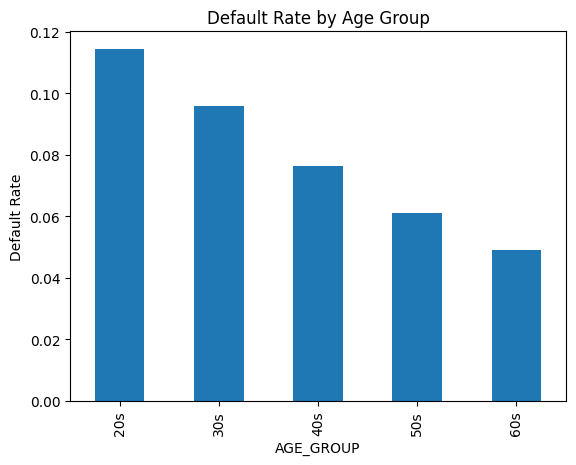

AGE_GROUP
20s    0.114438
30s    0.095918
40s    0.076411
50s    0.061210
60s    0.049177
Name: TARGET, dtype: float64

In [8]:
age_default = df.groupby("AGE_GROUP")["TARGET"].mean().sort_index()

age_default.plot(kind="bar")
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.show()

age_default

## 8. Hypothesis Validation: Income
### 8.1 Create Income Deciles (Quantiles)


In [9]:
# Create income deciles (10 equal-sized groups)
df["INCOME_DECILE"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=10,
    duplicates="drop"
)

df["INCOME_DECILE"].value_counts()

INCOME_DECILE
(112500.0, 135000.0]       48849
(180000.0, 225000.0]       44809
(99000.0, 112500.0]        36907
(25649.999, 81000.0]       33391
(147150.0, 162000.0]       31120
(162000.0, 180000.0]       30704
(81000.0, 99000.0]         30280
(270000.0, 117000000.0]    27161
(225000.0, 270000.0]       19957
(135000.0, 147150.0]        4333
Name: count, dtype: int64

### 8.2 Default Rate by Income Level


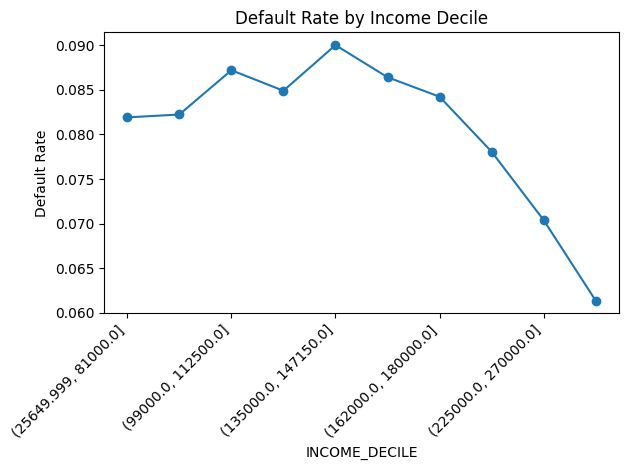

INCOME_DECILE
(25649.999, 81000.0]       0.081908
(81000.0, 99000.0]         0.082232
(99000.0, 112500.0]        0.087192
(112500.0, 135000.0]       0.084894
(135000.0, 147150.0]       0.090007
(147150.0, 162000.0]       0.086407
(162000.0, 180000.0]       0.084224
(180000.0, 225000.0]       0.078065
(225000.0, 270000.0]       0.070401
(270000.0, 117000000.0]    0.061375
Name: TARGET, dtype: float64

In [10]:
income_default = df.groupby("INCOME_DECILE")["TARGET"].mean()

income_default.plot(kind="line", marker="o")
plt.title("Default Rate by Income Decile")
plt.ylabel("Default Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

income_default

## 9. Hypothesis Validation: Leverage
### 9.1 Default Rate by Credit-to-Income Ratio


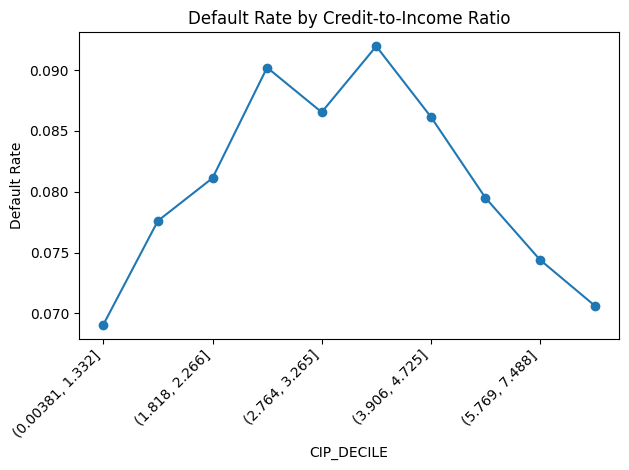

CIP_DECILE
(0.00381, 1.332]    0.069085
(1.332, 1.818]      0.077615
(1.818, 2.266]      0.081126
(2.266, 2.764]      0.090212
(2.764, 3.265]      0.086542
(3.265, 3.906]      0.091962
(3.906, 4.725]      0.086168
(4.725, 5.769]      0.079510
(5.769, 7.488]      0.074412
(7.488, 13.027]     0.070656
Name: TARGET, dtype: float64

In [11]:
df["CREDIT_INCOME_PERCENT"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
)

df["CREDIT_INCOME_PERCENT"] = df["CREDIT_INCOME_PERCENT"].clip(
    upper=df["CREDIT_INCOME_PERCENT"].quantile(0.99)
)

df["CIP_DECILE"] = pd.qcut(
    df["CREDIT_INCOME_PERCENT"],
    q=10,
    duplicates="drop"
)

cip_default = df.groupby("CIP_DECILE")["TARGET"].mean()

cip_default.plot(kind="line", marker="o")
plt.title("Default Rate by Credit-to-Income Ratio")
plt.ylabel("Default Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

cip_default

## 10. Baseline Findings Summary

Key insights from exploratory analysis:

1. Default rate is approximately 8%, indicating a highly imbalanced classification problem.
2. Default risk decreases significantly with age; borrowers in their 20s show the highest risk.
3. Higher income levels are associated with lower default probability.
4. Credit-to-Income ratio strongly correlates with default risk, reflecting repayment pressure.

Overall Conclusion:
Age, income, and leverage (credit-to-income ratio) are meaningful risk segmentation variables and should be included in predictive modeling.